# Stefan's ice-growth law: forward and backward Euler

Companion notebook for Section 4.1.2 of `Lec4.tex`. Solves Stefan's ice-growth law
$$
\frac{du}{dt} = \frac{D}{u}, \qquad u(0) = c,
$$
with the forward Euler method (Algorithm 4.1) and the backward Euler method with
Newton subiterations (Algorithm 4.2), and compares both against the exact solution
$u(t) = \sqrt{2Dt}$.

**A practical wrinkle.** The right-hand side $f(t,u) = D/u$ is singular at $u=0$, so
we cannot literally start either scheme from $u_0 = 0$: the very first forward Euler
step, and the very first Newton iteration for backward Euler, would both require
evaluating $D/0$. Hence we start the ODE solver with non-zero initial conditions. Below we cheat and borrow the value from the exact solution at a small positive time. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# parameters
D = 1.0
delta_t = 0.01
T = 1.0
tol = 1e-10
max_newton_iter = 50

# exact solution, used both for reference and to regularize the singular IC
def u_exact(t):
    return np.sqrt(2 * D * t)

# start one step size after t=0 to avoid dividing by u=0
t0 = delta_t
c = u_exact(t0)
u0 = c
N = int(round((T - t0) / delta_t))

In [3]:
def forward_euler_stefan(u0, t0, D, delta_t, N):
    """Algorithm 4.1 applied to f(t,u) = D/u."""
    t = t0 + delta_t * np.arange(N + 1)
    u = np.empty(N + 1)
    u[0] = u0
    for n in range(N):
        u[n + 1] = u[n] + delta_t * D / u[n]
    return t, u

In [4]:
def backward_euler_newton_stefan(u0, t0, D, delta_t, N, tol=1e-10, max_iter=50):
    """Algorithm 4.2 applied to f(t,u) = D/u.

    For this f we have g(v) = v - u_n - delta_t*D/v and
    g'(v) = 1 + delta_t*D/v**2, so each Newton step is
    v_{k+1} = v_k - g(v_k)/g'(v_k).
    """
    t = t0 + delta_t * np.arange(N + 1)
    u = np.empty(N + 1)
    u[0] = u0
    newton_iters = np.empty(N, dtype=int)

    for n in range(N):
        v = u[n]
        for k in range(max_iter):
            g = v - u[n] - delta_t * D / v
            g_prime = 1 + delta_t * D / v**2
            v_new = v - g / g_prime
            if abs(v_new - v) < tol:
                v = v_new
                break
            v = v_new
        newton_iters[n] = k + 1
        u[n + 1] = v

    return t, u, newton_iters

In [5]:
t_fe, u_fe = forward_euler_stefan(u0, t0, D, delta_t, N)
t_be, u_be, newton_iters = backward_euler_newton_stefan(
    u0, t0, D, delta_t, N, tol=tol, max_iter=max_newton_iter
)
u_ex = u_exact(t_fe)

print(f"D = {D}, delta_t = {delta_t}, t0 = {t0}, N = {N} steps")
print(f"average Newton subiterations per step: {newton_iters.mean():.2f} "
      f"(max {newton_iters.max()})")

D = 1.0, delta_t = 0.01, t0 = 0.01, N = 99 steps
average Newton subiterations per step: 3.12 (max 5)


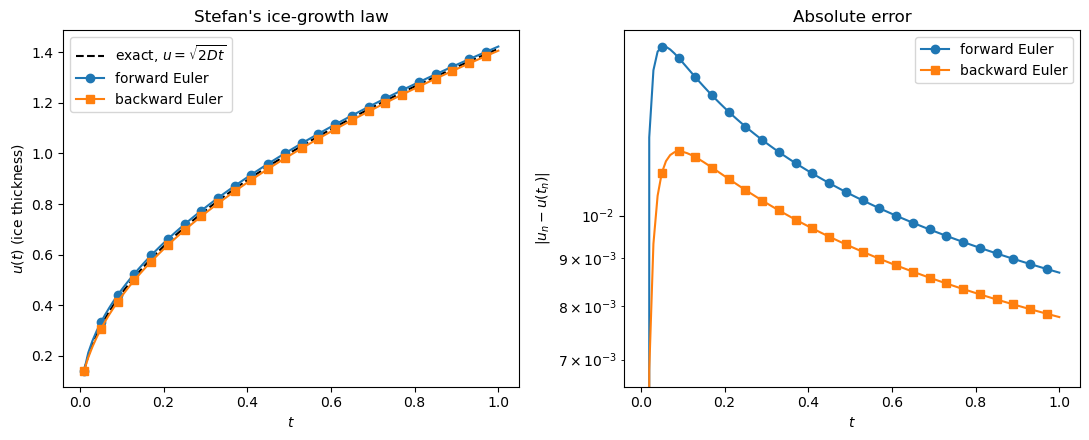

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(t_fe, u_ex, "k--", label=r"exact, $u=\sqrt{2Dt}$")
axes[0].plot(t_fe, u_fe, "o-", markevery=max(N // 20, 1), label="forward Euler")
axes[0].plot(t_be, u_be, "s-", markevery=max(N // 20, 1), label="backward Euler")
axes[0].set_xlabel("$t$")
axes[0].set_ylabel("$u(t)$ (ice thickness)")
axes[0].set_title("Stefan's ice-growth law")
axes[0].legend()

axes[1].semilogy(t_fe, np.abs(u_fe - u_ex), "o-", markevery=max(N // 20, 1),
                  label="forward Euler")
axes[1].semilogy(t_be, np.abs(u_be - u_ex), "s-", markevery=max(N // 20, 1),
                  label="backward Euler")
axes[1].set_xlabel("$t$")
axes[1].set_ylabel("$|u_n - u(t_n)|$")
axes[1].set_title("Absolute error")
axes[1].legend()

fig.tight_layout()
fig.savefig(f"stefan_ice_growth_dt{delta_t:g}.png", dpi=300, bbox_inches="tight")
plt.show()

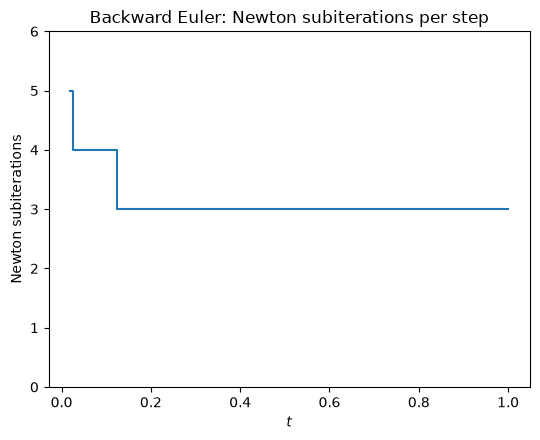

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.step(t_be[1:], newton_iters, where="mid")
ax.set_xlabel("$t$")
ax.set_ylabel("Newton subiterations")
ax.set_title("Backward Euler: Newton subiterations per step")
ax.set_yticks(range(0, newton_iters.max() + 2))

fig.tight_layout()
fig.savefig(f"stefan_newton_iters_dt{delta_t:g}.png", dpi=300, bbox_inches="tight")
plt.show()